In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(cowplot)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”


# Load Object

In [2]:
so <- readRDS(file = 'vst3_temp.rds')
so

An object of class Seurat 
18129 features across 1128684 samples within 1 assay 
Active assay: RNA (18129 features, 0 variable features)
 44 layers present: counts.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2, counts.2.1, counts.2.1.1, counts.2.1.1.1, counts.2.1.1.1.1, counts.2.1.1.1.1.1, counts.2.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.

In [3]:
table(so$AIFI_PBMC.Flex_L1)


         B cell              DC     Erythrocyte             ILC        Monocyte 
          67344            3030             268             630           62746 
        NK cell        Platelet Progenitor cell          T cell 
          28023            1937             824          963882 

# Basic QC T cells

In [4]:
t_cells <- subset(so, AIFI_PBMC.Flex_L1 == 'T cell')

In [5]:
rm(so)

In [6]:
table(is.na(t_cells$scrublet_call))


 FALSE   TRUE 
909311  54571 

In [7]:
t_cells$scrublet_call <- tidyr::replace_na(data = t_cells$scrublet_call, replace = 0)

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



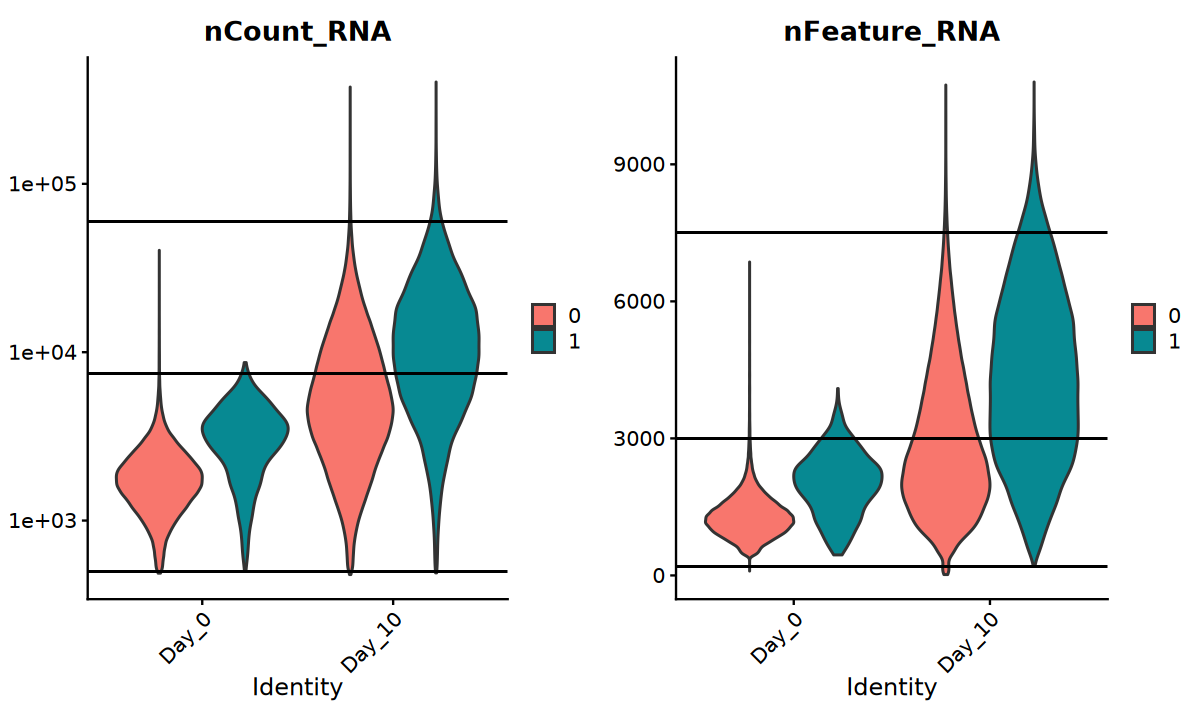

In [14]:
options(repr.plot.width = 10, repr.plot.height = 6)
p1 <- VlnPlot(t_cells, features = 'nCount_RNA', group.by = 'Day', pt.size = 0, log = T, split.by = 'scrublet_call') & 
    geom_hline(yintercept = 500) & geom_hline(yintercept = 7500) & geom_hline(yintercept = 60000)
p2 <- VlnPlot(t_cells, features = 'nFeature_RNA', group.by = 'Day', pt.size = 0, split.by = 'scrublet_call') & 
    geom_hline(yintercept = 200) & geom_hline(yintercept = 3000) & geom_hline(yintercept = 7500)
plot_grid(p1,p2,ncol=2)

In [15]:
so_split <- SplitObject(t_cells, split.by = 'Day')

In [16]:
so_split$Day_0

An object of class Seurat 
18129 features across 79328 samples within 1 assay 
Active assay: RNA (18129 features, 0 variable features)
 3 layers present: counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1

In [18]:
so_split$Day_0 <- subset(so_split$Day_0, nCount_RNA > 500 & nCount_RNA < 7500 & scrublet_call == 0)
so_split$Day_0

An object of class Seurat 
18129 features across 77930 samples within 1 assay 
Active assay: RNA (18129 features, 0 variable features)
 3 layers present: counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1

In [19]:
so_split$Day_10

An object of class Seurat 
18129 features across 884554 samples within 1 assay 
Active assay: RNA (18129 features, 0 variable features)
 41 layers present: counts.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2, counts.2.1, counts.2.1.1, counts.2.1.1.1, counts.2.1.1.1.1, counts.2.1.1.1.1.1, counts.2.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1

In [20]:
so_split$Day_10 <- subset(so_split$Day_10, nCount_RNA > 500 & nCount_RNA < 60000 & scrublet_call == 0)
so_split$Day_10

An object of class Seurat 
18129 features across 821327 samples within 1 assay 
Active assay: RNA (18129 features, 0 variable features)
 41 layers present: counts.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2, counts.2.1, counts.2.1.1, counts.2.1.1.1, counts.2.1.1.1.1, counts.2.1.1.1.1.1, counts.2.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1

In [22]:
filtered_cells <- c(so_split$Day_0$barcodes, so_split$Day_10$barcodes)
length(filtered_cells)

[1] 899257

In [23]:
t_cells_filtered <- subset(t_cells, barcodes %in% filtered_cells)
t_cells_filtered

An object of class Seurat 
18129 features across 899257 samples within 1 assay 
Active assay: RNA (18129 features, 0 variable features)
 44 layers present: counts.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2, counts.2.1, counts.2.1.1, counts.2.1.1.1, counts.2.1.1.1.1, counts.2.1.1.1.1.1, counts.2.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1

# Clustering + Clean up

In [25]:
table(t_cells_filtered$AIFI_PBMC.Flex_L2)


                 ASDC         CD14 monocyte         CD16 monocyte 
                   37                  9408                  1142 
   CD56bright NK cell       CD56dim NK cell                 CD8aa 
                   90                  1732                   678 
            DN T cell       Effector B cell           Erythrocyte 
                 5581                     1                   681 
                  ILC                  MAIT         Memory B cell 
                  220                 37707                   802 
    Memory CD4 T cell     Memory CD8 T cell          Naive B cell 
               142799                149974                  9145 
     Naive CD4 T cell      Naive CD8 T cell           Plasma cell 
                67929                129646                  5743 
             Platelet       Progenitor cell Proliferating NK cell 
                  148                   110                 11625 
 Proliferating T cell   Transitional B cell                  

In [26]:
t_cells_filtered <- subset(t_cells_filtered, AIFI_PBMC.Flex_L2 %in% c('DN T cell','MAIT','Memory CD4 T cell','Memory CD8 T cell','Naive CD4 T cell',
                                                                      'Naive CD8 T cell','Proliferating T cell','Treg','gdT'))
t_cells_filtered

An object of class Seurat 
18129 features across 856496 samples within 1 assay 
Active assay: RNA (18129 features, 0 variable features)
 44 layers present: counts.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2, counts.2.1, counts.2.1.1, counts.2.1.1.1, counts.2.1.1.1.1, counts.2.1.1.1.1.1, counts.2.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1, counts.2.1.1.1

In [27]:
t_cells_filtered <- NormalizeData(t_cells_filtered) %>% FindVariableFeatures() %>% ScaleData() %>% RunPCA() %>% 
        RunUMAP(dims=1:25)

Normalizing layer: counts.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1

Normalizing layer: counts.2

Normalizing layer: counts.2.1

Normalizing layer: counts.2.1.1

Normalizing layer: counts.2.1.1.1

Normalizing layer: counts.2.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1.1.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1.1.1.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1.1.1.1.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1

Normalizing layer: counts.2.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1.1

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



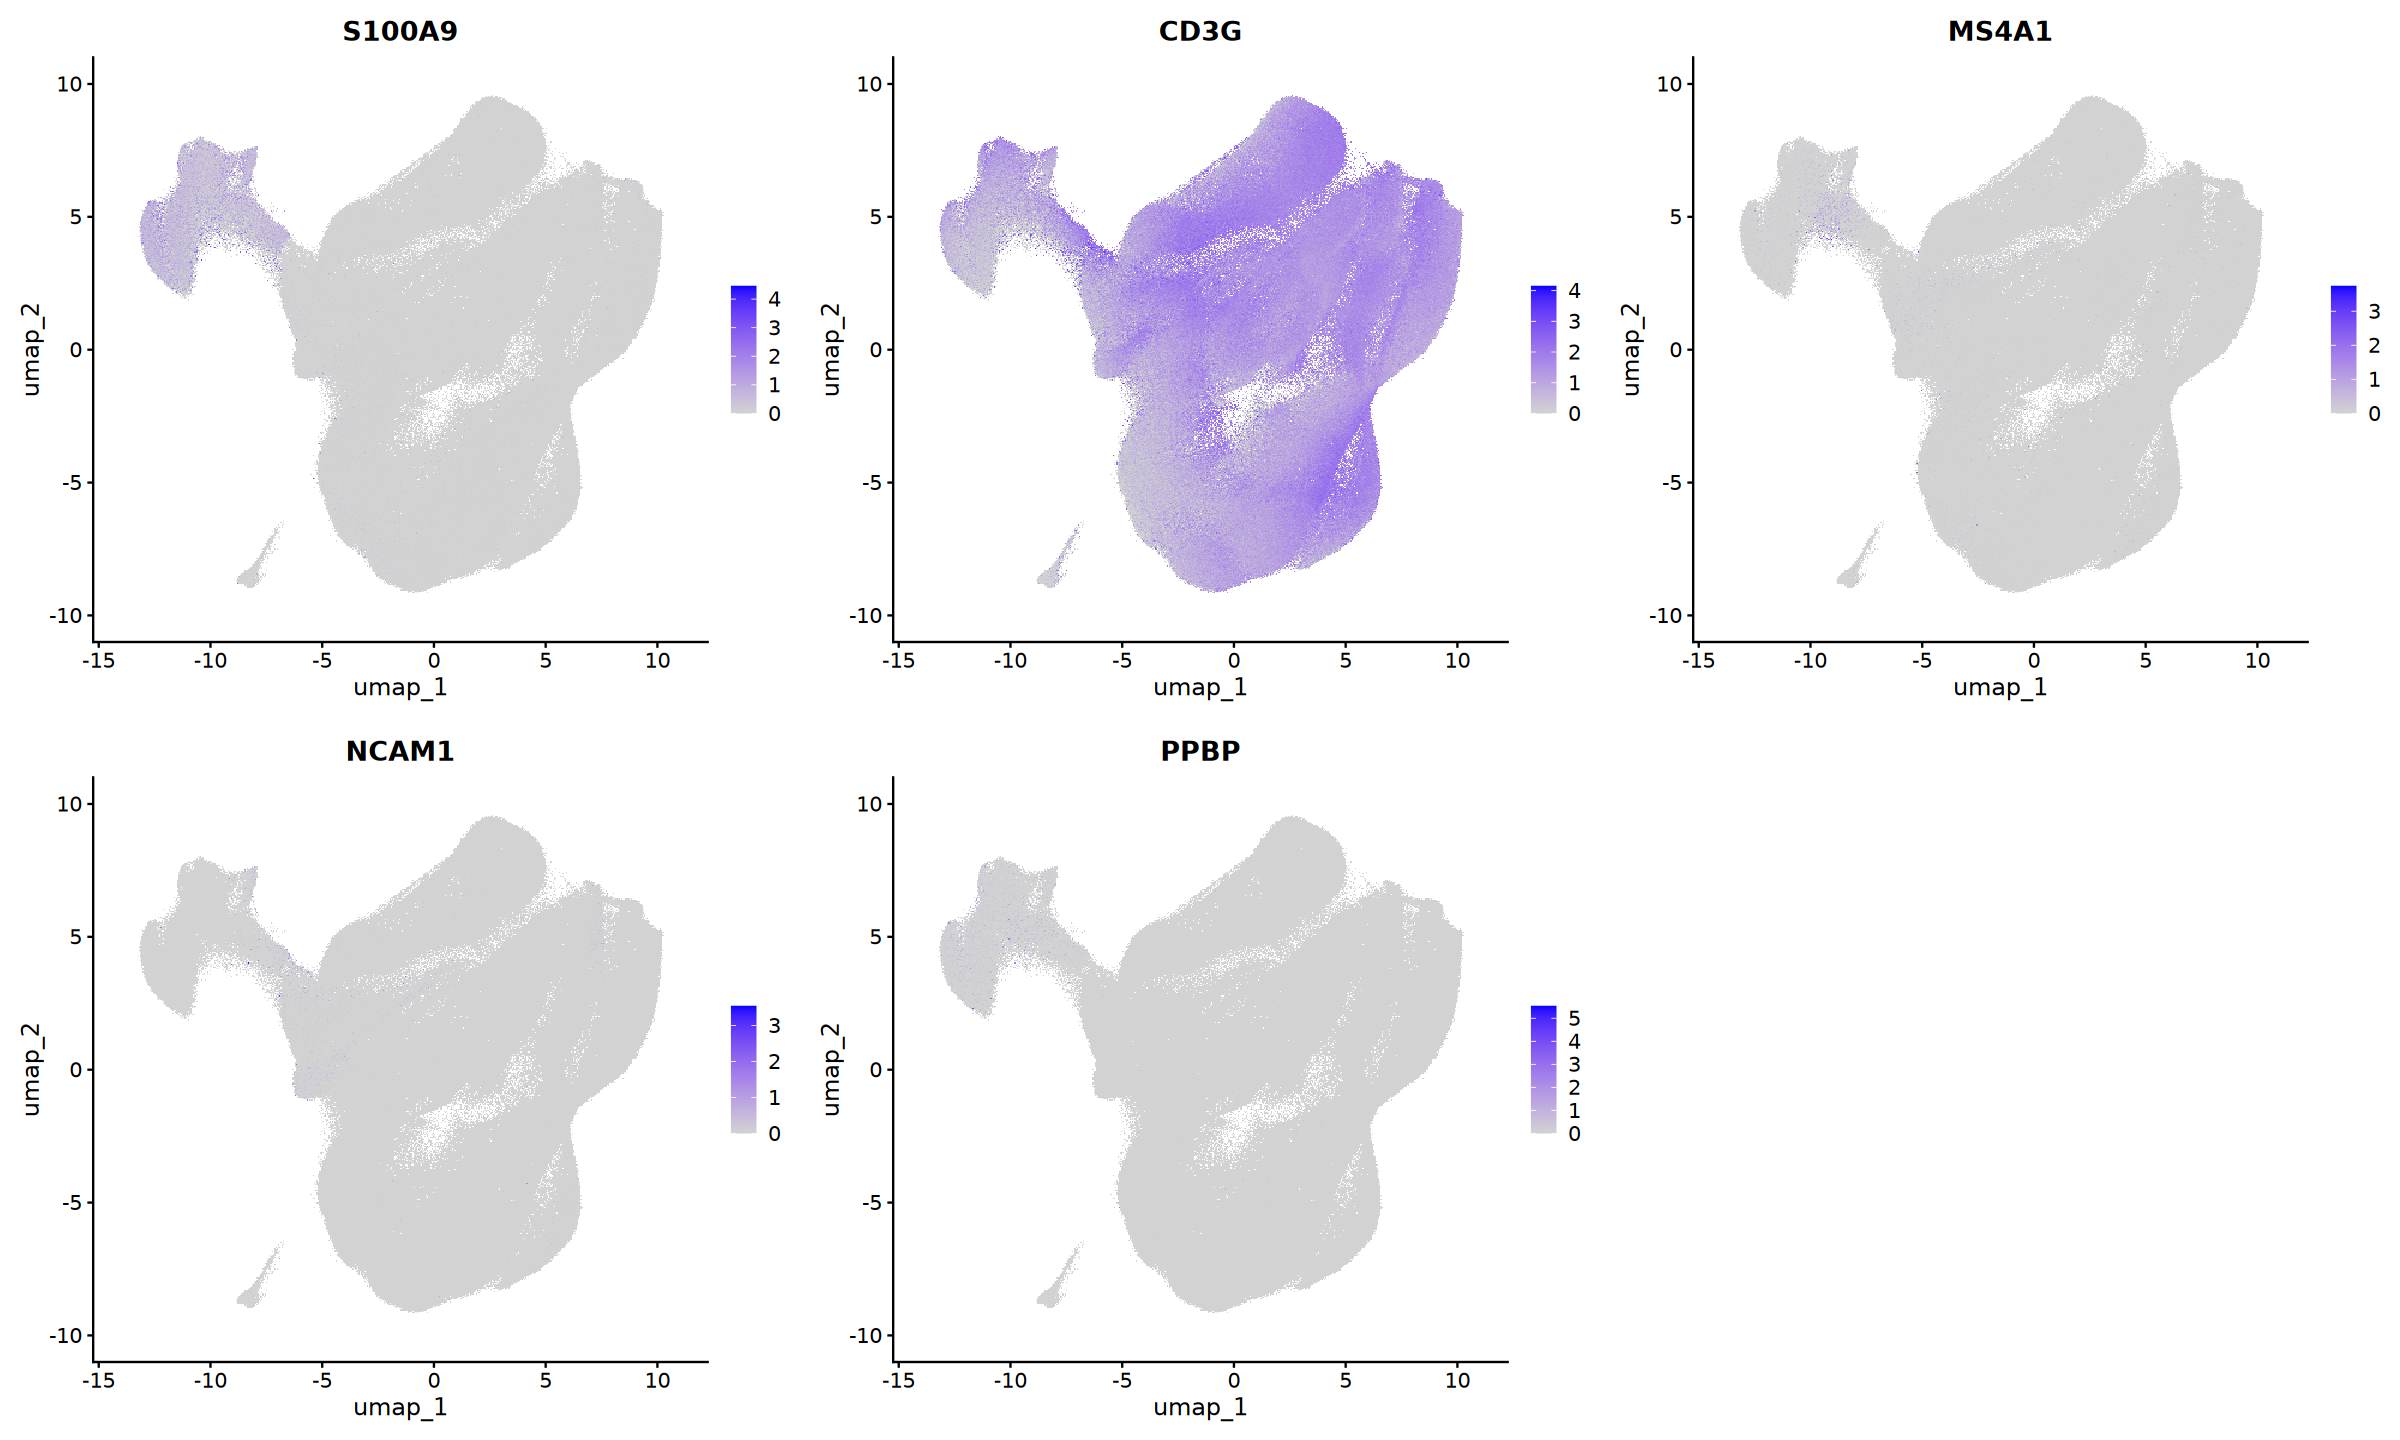

In [28]:
options(repr.plot.width = 20, repr.plot.height = 12)
p1 <- FeaturePlot(t_cells_filtered, features = 'S100A9')
p2 <- FeaturePlot(t_cells_filtered, features = 'CD3G')
p3 <- FeaturePlot(t_cells_filtered, features = 'MS4A1')
p4 <- FeaturePlot(t_cells_filtered, features = 'NCAM1')
p5 <- FeaturePlot(t_cells_filtered, features = 'PPBP')
plot_grid(p1,p2,p3,p4,p5,ncol=3)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“annotation$theme is not a valid theme.
Please use `theme()` to construct themes.”


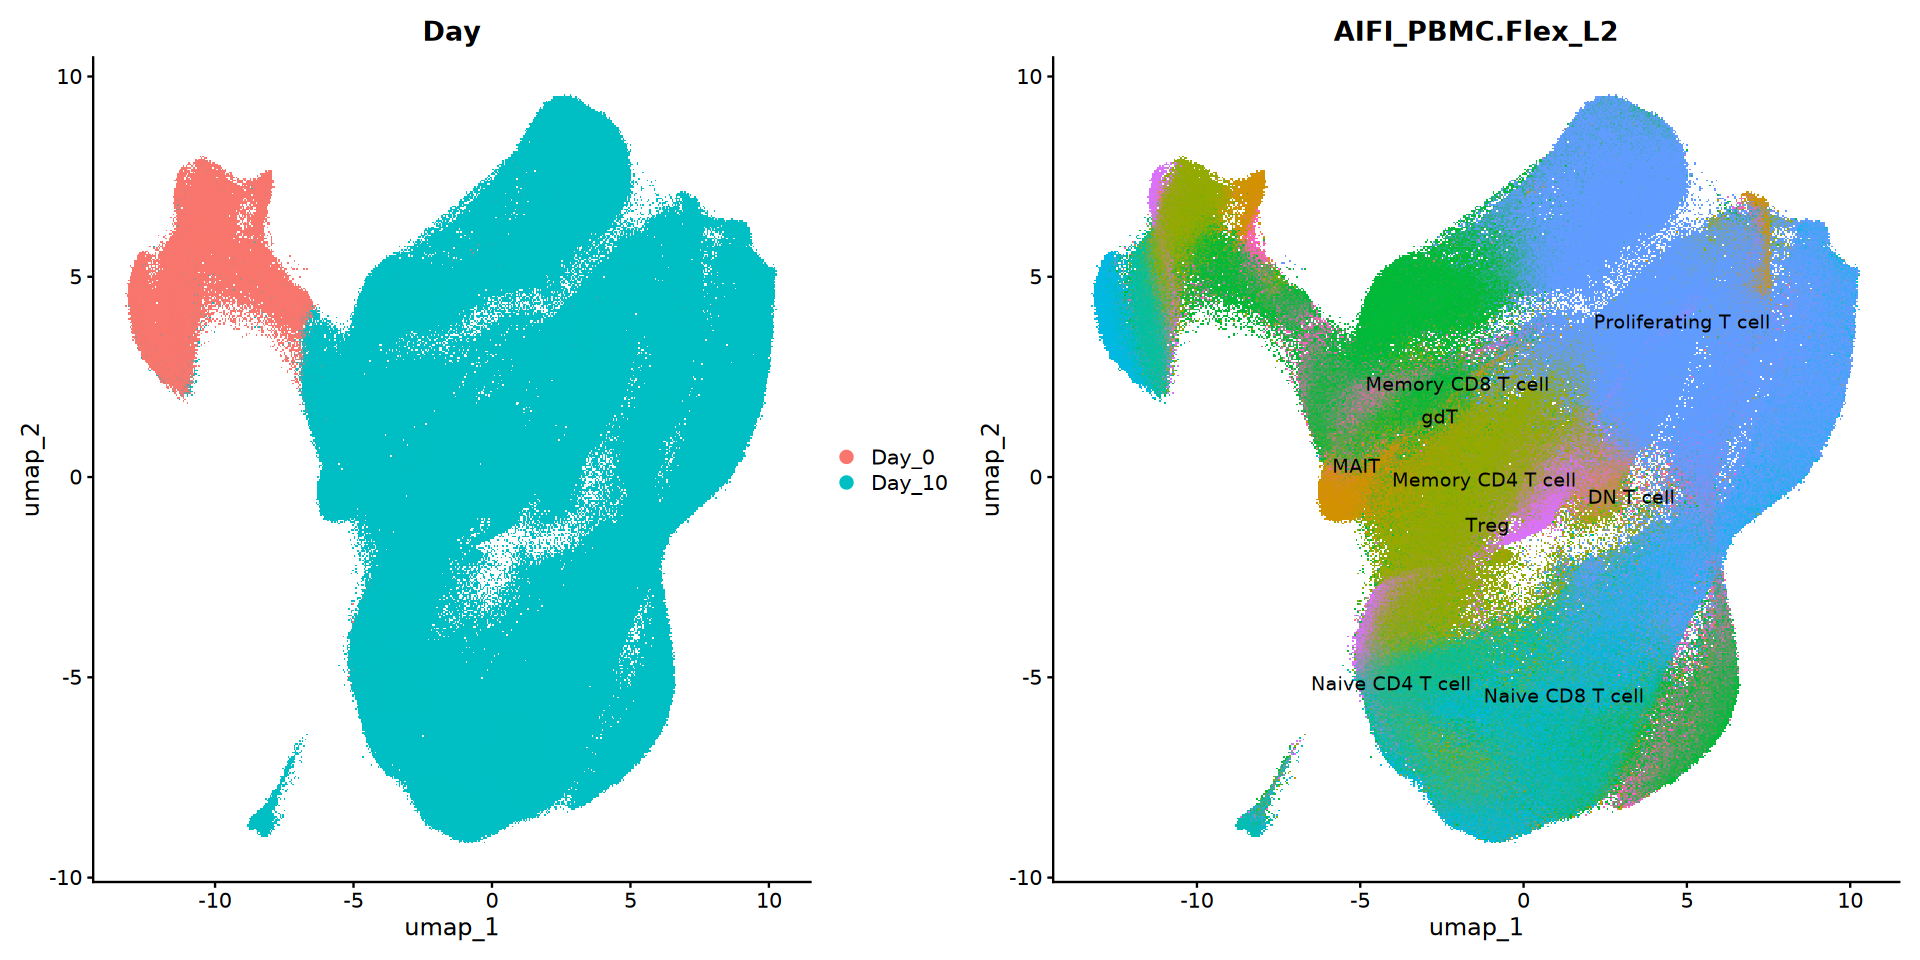

In [29]:
options(repr.plot.width = 16, repr.plot.height = 8)
p1 <- DimPlot(t_cells_filtered, group.by = 'Day')
p2 <- DimPlot(t_cells_filtered, group.by = 'AIFI_PBMC.Flex_L2', label = TRUE, repel = TRUE) & NoLegend()
plot_grid(p1,p2,ncol=2)

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



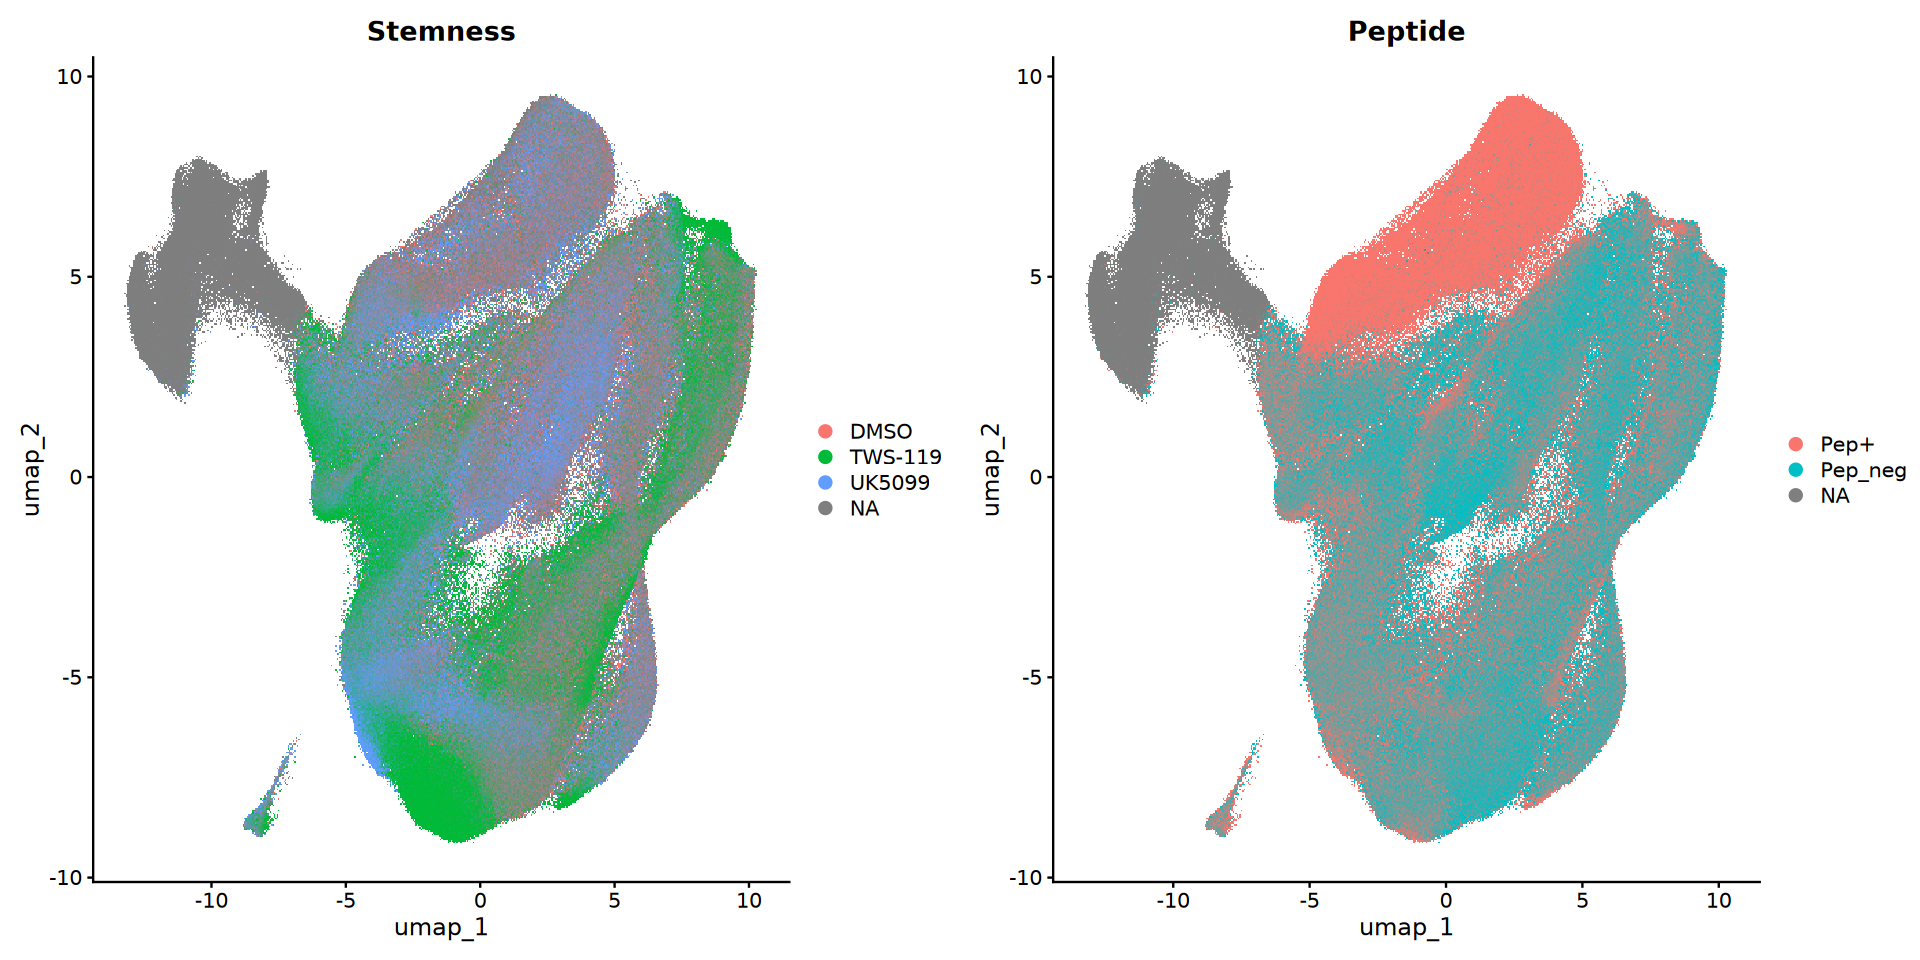

In [32]:
options(repr.plot.width = 16, repr.plot.height = 8)
p1 <- DimPlot(t_cells_filtered, group.by = 'Stemness')
p2 <- DimPlot(t_cells_filtered, group.by = 'Peptide')
plot_grid(p1,p2,ncol=2)

In [ ]:
saveRDS(t_cells_filtered, 'vst3_t_cells_filtered.rds')

In [2]:
t_cells_filtered <- readRDS('vst3_t_cells_filtered.rds')

In [3]:
t_cells_filtered <- FindNeighbors(t_cells_filtered, dims = 1:20) %>% FindClusters(resolution = 1)

Computing nearest neighbor graph

Warning message:
“package ‘future’ was built under R version 4.4.3”
Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 856496
Number of edges: 20872564

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9032
Number of communities: 32
Elapsed time: 858 seconds


1 singletons identified. 31 final clusters.



Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Warning message:
“annotation$theme is not a valid theme.
Please use `theme()` to construct themes.”


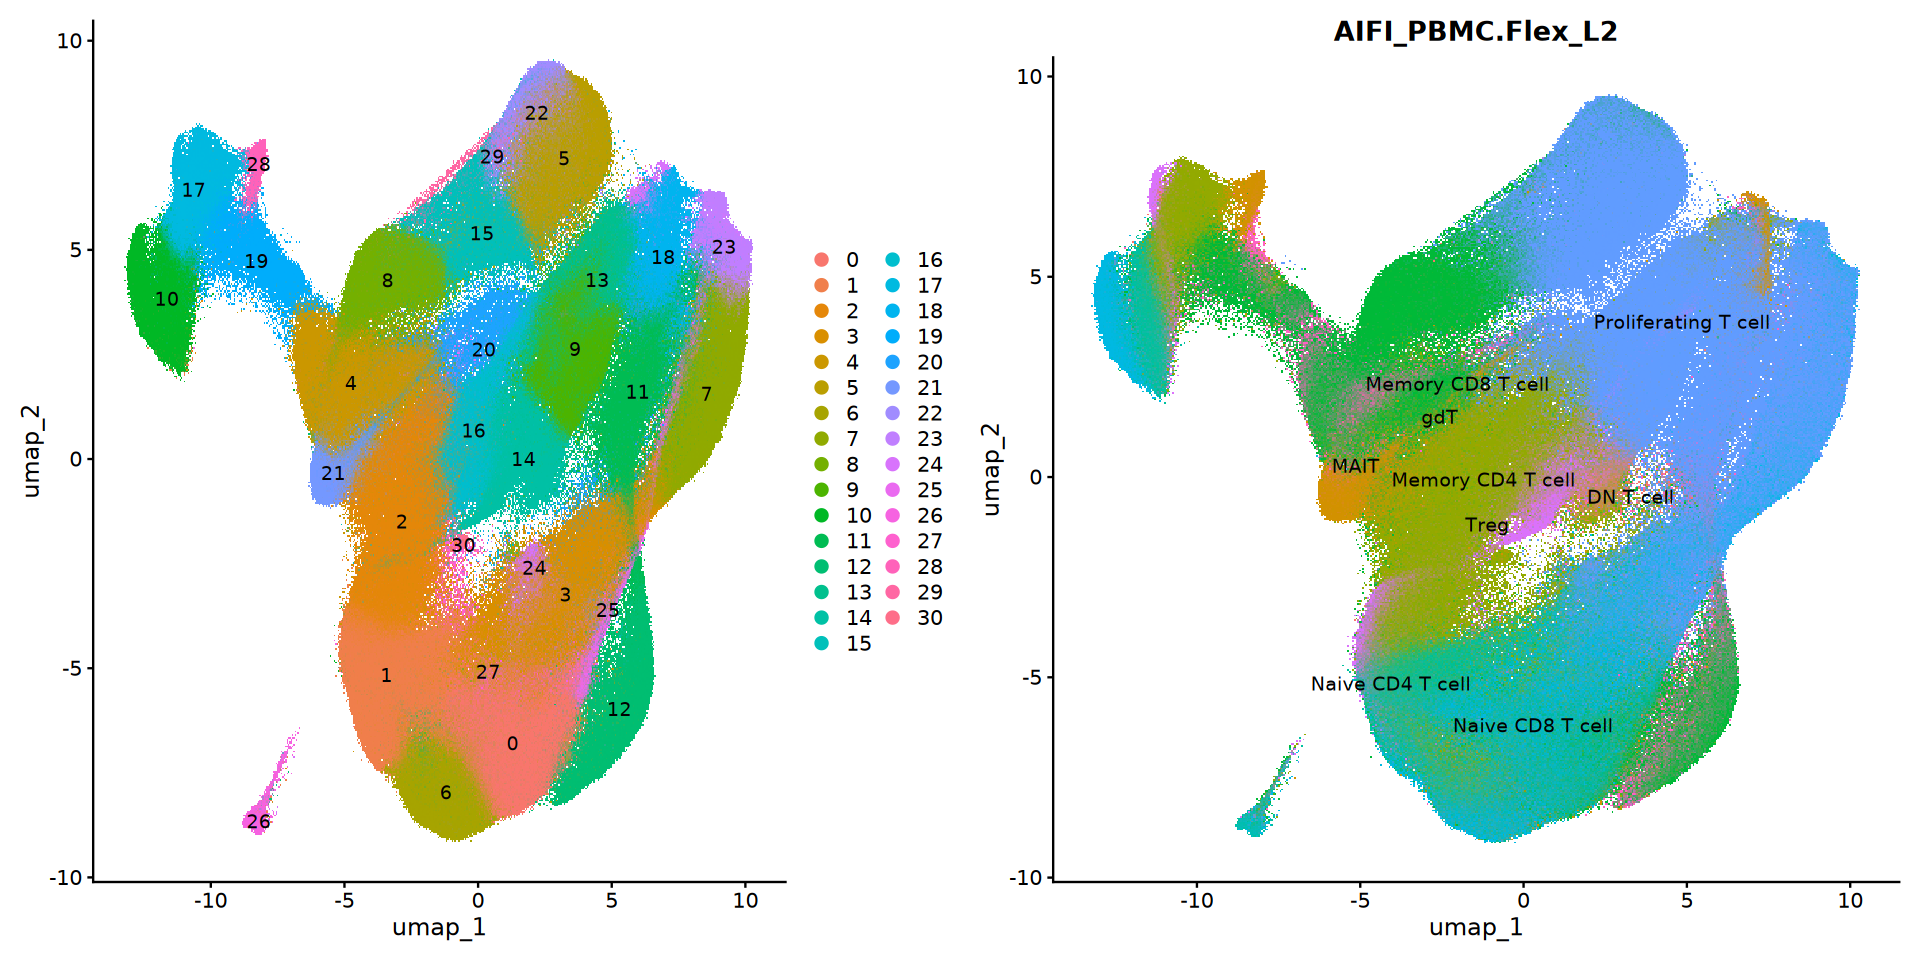

In [4]:
options(repr.plot.width = 16, repr.plot.height = 8)
p1 <- DimPlot(t_cells_filtered, label = T)
p2 <- DimPlot(t_cells_filtered, group.by = 'AIFI_PBMC.Flex_L2', label = TRUE, repel = TRUE) & NoLegend()
plot_grid(p1,p2,ncol=2)

In [5]:
saveRDS(t_cells_filtered, 'vst3_t_cells_clustered.rds')